<a href="https://colab.research.google.com/github/Ramkanc/Capstone_IIITH/blob/Capstone1_MultiModel_V4/V3_Capstone1_RamK_Multi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import torch
import torchvision
from torch import nn
from torch import optim
import torch.nn.functional as F

from torchsummary import summary
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision.datasets import ImageFolder

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from os import listdir
import pandas as pd

In [2]:
import PIL
from PIL import Image

In [3]:
from sklearn.model_selection import train_test_split

# Import FLickr8k dataset from Kaggle hub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

100%|██████████| 1.04G/1.04G [00:10<00:00, 105MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1


In [5]:
found_directories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
found_files =[f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
print (found_directories)
print (found_files)

['Images']
['captions.txt']


In [6]:
image_dir= os.path.join(path, found_directories[0])
print(image_dir)

/root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images


In [7]:
labels_file = os.path.join(path, found_files[0])

In [8]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.max_colwidth', None) # Show full column width

# Prepare Pandas dataframe for Captions to make it ready for dataset

In [9]:
raw_captions = pd.read_csv(labels_file, delimiter=',',header=0)

In [10]:
raw_captions.shape

(40455, 2)

In [11]:
raw_captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .


In [12]:
# to remove .jpg from raw_captions['image'] column
raw_captions['image'] = raw_captions['image'].str.replace('.jpg', '')

In [13]:
# dataframe which shows count of values from raw_captions[image] column
value_counts = raw_captions['image'].value_counts().reset_index()
value_counts.columns = ['image', 'count']
value_counts['count'].unique().tolist()

[5]

Find maximum word length caption

In [14]:
word_count= [len(text.split()) for text in raw_captions['caption']]
print(f"Maximum words count in captions {max(word_count)}")

Maximum words count in captions 38


Arrange captions separate columns and create another dataframe

In [15]:
unique_images = raw_captions['image'].unique()

In [16]:
captions_df = raw_captions.copy()

In [17]:
captions_df['image'] = captions_df.groupby('image').cumcount().add(1).astype(str).map(lambda x: '_{}'.format(x)).radd(captions_df['image'])

In [18]:
captions_df.head(20)

,image,caption
0,1000268201_693b08cb0e_1,A child in a pink dress is climbing up a set of stairs in an entry way .
1,1000268201_693b08cb0e_2,A girl going into a wooden building .
2,1000268201_693b08cb0e_3,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e_4,A little girl climbing the stairs to her playhouse .
4,1000268201_693b08cb0e_5,A little girl in a pink dress going into a wooden cabin .
5,1001773457_577c3a7d70_1,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70_2,A black dog and a tri-colored dog playing with each other on the road .
7,1001773457_577c3a7d70_3,A black dog and a white dog with brown spots are staring at each other in the street .
8,1001773457_577c3a7d70_4,Two dogs of different breeds looking at each other on the road .
9,1001773457_577c3a7d70_5,Two dogs on pavement moving toward each other .


In [19]:
#capt_dic = raw_captions.groupby('image')['caption'].apply(list).to_dict()

In [20]:
#capt_df = pd.DataFrame.from_dict(capt_dic, orient='index', columns=['caption1','caption2','caption3','caption4','caption5' ])
#capt_df = capt_df.reset_index()  # Reset index to make 'A' a regular column

In [21]:
#capt_df.head()

# Prepare Images data to make them ready for dataset

In [22]:
# a funcntion to resize image to 224 X224 and change the color to RGB by using CV2
def resize_and_convert_to_rgb(image_path):
    """
    Resizes an image to 224x224 and converts it to RGB color space using OpenCV.

    Args:
        image_path: The path to the image file.

    Returns:
        A NumPy array representing the resized and converted image, or None if the image cannot be loaded.
    """
    try:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error: Could not load image at {image_path}")
            return None

        img = cv2.resize(img, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
        return img
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [23]:
# Custom dataset prepartion with transformations
class Flickr8kDataset(Dataset):
    def __init__(self, root_dir, captions_df, transform=None):
        """
        Args:
            root_dir (str): Directory containing all the images.
            captions_df(dataframe): Captions dataframe
            transform (callable, optional): Optional additional transforms to be applied
                on an image after resizing and conversion.
        """
        self.root_dir = root_dir
        self.captions_data = pd.read_csv(captions_df, header=None, names=["image", "caption"])
        self.transform = transform

    def __len__(self):
        return len(self.captions_data)

    def __getitem__(self, idx):
        # Get the image file name and caption
        img_name = os.path.join(self.root_dir, self.captions_data.iloc[idx])
        img_name = img_name +'.jpg'
        caption = self.captions_data.iloc[idx, 0:5]

        # Apply resizing and RGB conversion
        image = resize_and_convert_to_rgb(img_name)
        if image is None:
            raise ValueError(f"Image at {img_name} could not be loaded.")

        # Convert the image to a PyTorch tensor
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)  # HWC to CHW format

        # Apply any additional transformations, if specified
        if self.transform:
            image = self.transform(image)

        return image, caption

In [24]:
#train_df, val_df = train_test_split(captions_df, test_size=0.2, random_state=0)

Split the data frame Train and Test

# Preprocessing steps for captions

In [25]:
from transformers import BertTokenizer
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [26]:
# preprocessing to change lower case, remove puctuations and stop words
def preprocess_caption(caption):
    """Preprocesses the caption text.

    Args:
        caption (str): The caption text.

    Returns:
        str: The preprocessed caption text.
    """
    # Lowercase the text
    caption = caption.lower()

    # Remove punctuation (fixed regex for removing special characters)
    caption = re.sub(r"[^a-zA-Z0-9 ]", "", caption)

    # Remove stop words (using NLTK)
    stop_words = set(stopwords.words('english'))
    words = caption.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    caption = " ".join(filtered_words)

    # Add special tokens for start and end of sequence (if needed by your model)
    # caption = "[CLS] " + caption + " [SEP]"  # Example for BERT

    return caption

In [27]:
# tokenizing using bert
def tokenize_caption(caption, tokenizer, max_length=32):
    """Tokenizes the preprocessed caption text.

    Args:
        caption (str): The preprocessed caption text.
        tokenizer (transformers.BertTokenizer): The tokenizer object.
        max_length (int): Maximum length for tokenized captions.

    Returns:
        tuple: A tuple containing token IDs and attention mask.
    """
    inputs = tokenizer(
        caption,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    return inputs["input_ids"].squeeze(0), inputs["attention_mask"].squeeze(0)

In [28]:
# Custom dataset for catpitons
class CaptionsDataset(Dataset):
    def __init__(self, captions_df, tokenizer, max_length=104):
        self.captions_df = captions_df
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.captions_df)

    def __getitem__(self, idx):
        item = self.captions_df.iloc[idx]
        image_id = item['image']  # Get image ID (filename without extension)
        caption = item['caption']

        # Preprocess and tokenize the caption
        preprocessed_caption = preprocess_caption(caption)
        token_ids, attention_mask = tokenize_caption(preprocessed_caption, self.tokenizer, self.max_length)

        return token_ids, attention_mask, image_id

In [29]:
# Create a BertTokenizer instance
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [30]:
# Create the CaptionsDataset
captions_dataset = CaptionsDataset(captions_df, tokenizer, max_length=38)  # Adjust max_length as needed

In [31]:
# Create the DataLoader
captions_dataloader = DataLoader(captions_dataset, batch_size=16, shuffle=False)  # Adjust batch_size as needed

In [32]:
# To print the tokens and captions
count = 0  # Initialize a counter
for batch in captions_dataloader:
    for i in range(len(batch[0])):  # Iterate through items in the batch
        if count >= 10:
            break

        image_id = batch[2][i]
        token_ids = batch[0][i].tolist()  # Convert token_ids tensor to list
        tokens = tokenizer.convert_ids_to_tokens(token_ids)  # Convert token_ids to tokens

        print(f"Image ID: {image_id}")
        print(f"Token IDs: {token_ids}")
        print(f"Tokens: {tokens}")
        print("-" * 20)  # Separator

        count += 1  # Increment the counter

    if count >= 10:
        break

Image ID: 1000268201_693b08cb0e_1
Token IDs: [101, 2775, 5061, 4377, 8218, 2275, 5108, 4443, 2126, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens: ['[CLS]', 'child', 'pink', 'dress', 'climbing', 'set', 'stairs', 'entry', 'way', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
--------------------
Image ID: 1000268201_693b08cb0e_2
Token IDs: [101, 2611, 2183, 4799, 2311, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens: ['[CLS]', 'girl', 'going', 'wooden', 'building', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '

In [33]:
# Define a custom dataset class to preprocess the Images by using OpenCV
class CustomImageDataset(Dataset):
    def __init__(self, image_dir):
        """
        Args:
            image_dir (str): Path to the directory with images.
        """
        self.image_dir = image_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith(('jpg', 'png', 'jpeg'))]

    def preprocess_image_opencv(self, image_path):
        # Read the image using OpenCV
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Image not found at {image_path}")

        # Resize to 224x224
        image_resized = cv2.resize(image, (224, 224))

        # Convert from BGR to RGB
        image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

        # Normalize pixel values to [0, 1]
        image_normalized = image_rgb / 255.0

        # Reshape to CxHxW
        image_reshaped = np.transpose(image_normalized, (2, 0, 1))

        # Convert to PyTorch tensor
        image_tensor = torch.tensor(image_reshaped, dtype=torch.float32)

        # Normalize using ImageNet mean and std
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std

        return image_tensor

    def __len__(self):
        # Return the number of images
        return len(self.image_files)

    def __getitem__(self, idx):
        # Get the image path
        image_file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, image_file_name)

        # Preprocess the image
        image_tensor = self.preprocess_image_opencv(image_path)

        # Extract image ID (filename without extension)
        image_id = os.path.splitext(image_file_name)[0]

        # Return the processed tensor
        return image_tensor,image_id

# Data loader for Image Dataset

In [34]:
# Create an instance of the custom dataset
dataset = CustomImageDataset(image_dir)

# Create a DataLoader
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

In [35]:
# Iterate over the DataLoader
for batch_idx, (batch_images, image_ids) in enumerate(dataloader):
    print(f"Batch {batch_idx + 1}:")
    print(f"Shape: {batch_images.shape}")  # Expected: [batch_size, 3, 224, 224]
    print(f"Type: {batch_images.dtype}")  # Expected: torch.float32
    print(f"Image IDs: {image_ids}")  # Print the image IDs in the batch
    print (f"Image IDs type: {type(image_ids)}")
    break

Batch 1:
Shape: torch.Size([16, 3, 224, 224])
Type: torch.float32
Image IDs: ('3665549027_d7fb05d157', '17273391_55cfc7d3d4', '3632047678_f202609e50', '225909073_25c3c33a29', '2561212119_1af8cb9b5d', '3718892835_a3e74a3417', '2541701582_0a651c380f', '2797438951_88a3ed7541', '444881000_bba92e585c', '1975531316_8b00eeaaf7', '3222055946_45f7293bb2', '3346289227_198fced308', '3415113018_7b95ddcd11', '2404488732_ca1bbdacc2', '308307853_5a51fbdecc', '3619381206_5bc8b406f9')
Image IDs type: <class 'tuple'>


# Display preprocessed Images from Data loader

In [36]:
# Function to display a single image
def show_image(image_tensor):
    # Undo normalization for display (optional if you want raw pixel values)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = image_tensor * std + mean  # Denormalize

    # Convert from Tensor (CxHxW) to NumPy array (HxWxC)
    image_numpy = image_tensor.permute(1, 2, 0).numpy()
    image_numpy = np.clip(image_numpy, 0, 1)  # Clip values to [0, 1] for proper display

    # Display the image
    plt.imshow(image_numpy)
    plt.axis('off')

In [38]:
def display_images_from_dataloader(dataloader, num_images=10):
    images_shown = 0
    plt.figure(figsize=(15, 10))  # Adjust figure size for better visualization

    for batch_idx, (batch_images, image_ids) in enumerate(dataloader):
        for image_idx, image_tensor in enumerate(batch_images):
            if images_shown >= num_images:
                break

            # Get the image ID for the current image
            image_id = image_ids[image_idx]

            plt.subplot(2, 5, images_shown + 1)  # Create a 2x5 grid for 10 images
            show_image(image_tensor)
            plt.title(image_id)  # Set the image ID as the title
            images_shown += 1

        if images_shown >= num_images:
            break

    plt.tight_layout()
    plt.show()

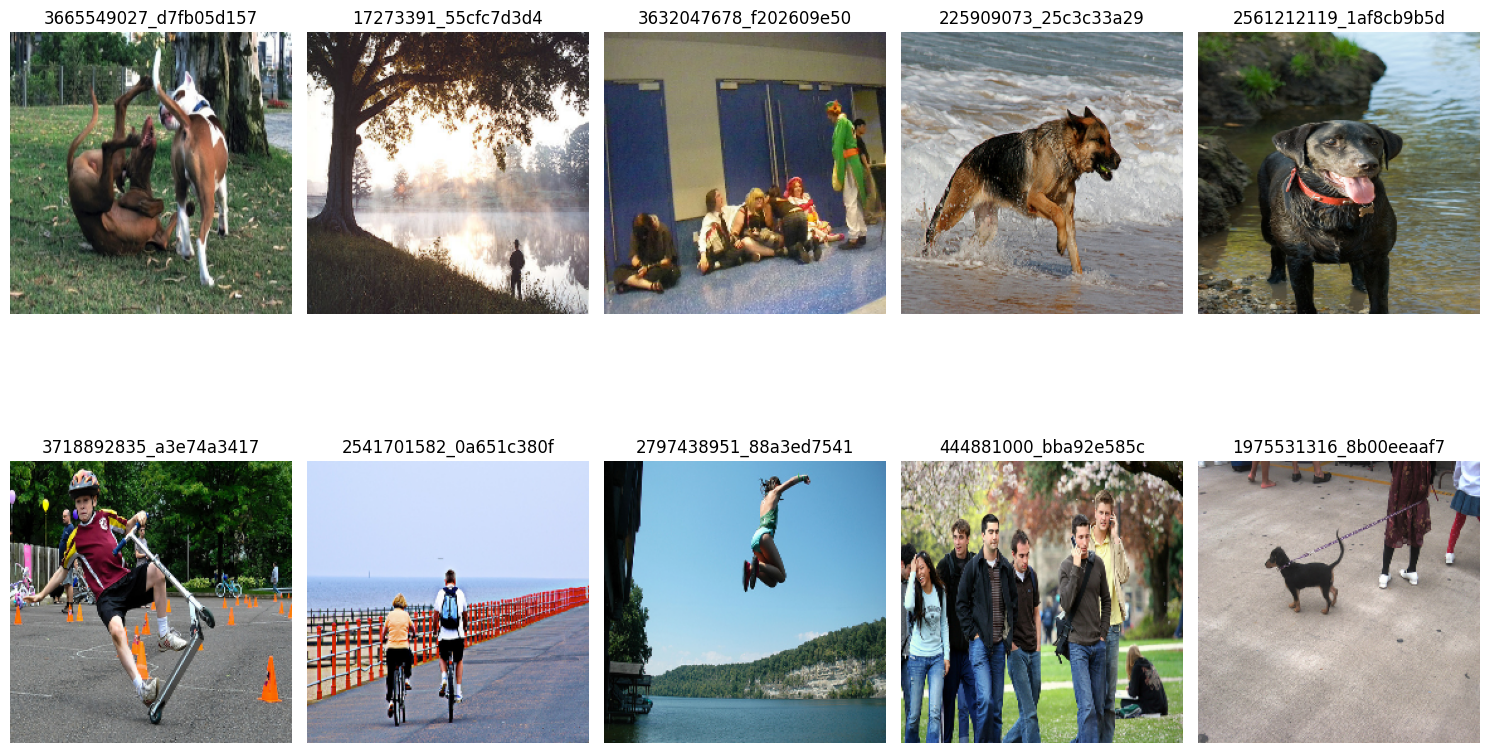

In [39]:
# Call the function to display images
display_images_from_dataloader(dataloader,num_images=10)

# Import Captions from the Local dump directory

Device setup CUDA

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Extract Image features with Encoder, Output the Image vector embeddings

In [41]:
class ImageEncoder(nn.Module):
    def __init__(self, embedding_size=256):  # adjust the embedding_size
        super(ImageEncoder, self).__init__()
        # Load pre-trained VGG16 model
        #vgg16 = models.vgg16(pretrained=True)
        #model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Remove the classification layer (last layer)
        #modules = list(vgg16.children())[:-1]
        modules = list(model.children())[:-1]

        # Create the feature extractor
        self.vgg16 = nn.Sequential(*modules)

        # Freeze the VGG16 parameters (optional)
        for param in self.vgg16.parameters():
            param.requires_grad = False

        # Add a linear layer to project to desired embedding size
        self.embedding_layer = nn.Linear(512 * 7 * 7, embedding_size)

#)

    def forward(self, images):
        features = self.vgg16(images)  # Extract features using VGG16
        features = features.view(features.size(0), -1)  # Flatten the features
        embeddings = self.embedding_layer(features)# Project to embedding space
        #embeddings = F.normalize(embeddings, p=2, dim=1)  # Normalize embeddings
        #embeddings = embeddings.flatten()
        return embeddings

    def process_dataloader(self, image_dataloader, device):
        all_embeddings = []
        all_image_ids = []
        for batch_idx, (images, image_ids) in enumerate(image_dataloader):
            # Move images to the appropriate device
            images = images.to(device)

            # Generate embeddings for the batch
            with torch.no_grad():  # Disable gradient calculation for inference
                batch_embeddings = self.forward(images)

            # Append embeddings to the list
            all_embeddings.append(batch_embeddings)
            all_image_ids.extend(image_ids)  # Extend the list with image IDs

        # Concatenate all embeddings
        all_embeddings = torch.cat(all_embeddings, dim=0)
        return all_embeddings, all_image_ids

In [42]:
# Create an instance of the ImageEncoder
image_encoder = ImageEncoder(embedding_size=256).to(device)  # Move model to the device

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 224MB/s]


In [43]:
print(summary(image_encoder, (3, 224, 224)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

# Collect the extracted Image embeddings

In [44]:
# Process the image dataloader and get embeddings
image_embeddings, image_ids = image_encoder.process_dataloader(dataloader, device)

In [45]:
# Print the shape and type of image embeddings
print(f"Image embeddings shape: {image_embeddings.shape}")
print(f"Image embeddings type: {image_embeddings.dtype}")
print(f"Number of image IDs: {len(image_ids)}")

Image embeddings shape: torch.Size([8091, 256])
Image embeddings type: torch.float32
Number of image IDs: 8091


# Create Encoder to extract Caption Embeddings from tokens

In [46]:
class CaptionEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1):
        super(CaptionEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)

    def forward(self, captions):
        embeddings = self.embedding(captions)  # Embed the captions
        _, (hidden, _) = self.lstm(embeddings)  # Pass through LSTM
        return hidden[-1]  # Return the last hidden state as the caption embedding

    def process_dataloader(self, captions_dataloader, device):
        all_embeddings = []
        all_image_ids = []
        for batch_idx, (token_ids, attention_masks, image_ids) in enumerate(captions_dataloader):
            # Move data to the appropriate device
            token_ids = token_ids.to(device)

            # Generate embeddings for the batch
            batch_embeddings = self.forward(token_ids)

            # Append embeddings to the list
            all_embeddings.append(batch_embeddings)
            all_image_ids.extend(image_ids)

        # Concatenate all embeddings
        all_embeddings = torch.cat(all_embeddings, dim=0)
        return all_embeddings, all_image_ids

In [47]:
vocab_size = tokenizer.vocab_size # vocabulary size from BERT tokenizer
embedding_dim = 256  #  embedding dimension matching to Image embedings
hidden_dim = 512  #  hidden dimension 512

In [48]:
caption_encoder = CaptionEncoder(vocab_size, embedding_dim, hidden_dim).to(device)

In [49]:
#%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


# Collecting Caption Embeddings from Encoder

In [50]:
caption_embeddings, caption_image_ids = caption_encoder.process_dataloader(captions_dataloader, device)

In [51]:
print(f"Caption embeddings shape: {caption_embeddings.shape}")
print(f"Caption embeddings type: {caption_embeddings.dtype}")
print(f"Number of caption IDs: {len(caption_image_ids)}")

Caption embeddings shape: torch.Size([40455, 512])
Caption embeddings type: torch.float32
Number of caption IDs: 40455


# Align the embeddings by projecting latent space and compute the similarity




1.   Normalise the embeddings before projecting
2.   Project embeddings on a  linear projection to map them to the same dimensional space.

# Compute Similarity Matrix:
3. Use the dot product to calculate similarity scores between all pairs of image and caption embeddings.

# Apply Contrastive Loss
4. Use a contrastive loss like InfoNCE to align positive pairs and separate negatives.
5. Define the temperature parameter:
The temperature (e.g., 0.07) controls the sharpness of the similarity distribution.

# Optimize and Train
6. During training, backpropagate the contrastive loss to update the projections and embeddings. Use an optimizer like Adam or SGD.

#Training Loop
7. You need to implement a loop to train the model and minimize the contrastive loss.

In [55]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example Embeddings (replace with actual data)
image_embeddings = torch.randn(8091, 256).to(device)
caption_embeddings = torch.randn(8091, 512).to(device)

#image_embeddings = image_embeddings / image_embeddings.norm(dim=1, keepdim=True)
#caption_embeddings = caption_embeddings / caption_embeddings.norm(dim=1, keepdim=True)

# Define learnable linear projections
image_projection = nn.Linear(256, 512).to(device)
caption_projection = nn.Identity().to(device)  # Caption embeddings are already in 512D space

# Hyperparameters
temperature = 0.07
learning_rate = 1e-3
epochs = 100
batch_size = 64

# Contrastive loss (CrossEntropy)
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(image_projection.parameters(), lr=learning_rate)

# Data loader setup
dataset = torch.utils.data.TensorDataset(image_embeddings, caption_embeddings)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Training loop
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in data_loader:
        img_batch, cap_batch = batch

        # Move batch data to device
        img_batch = img_batch.to(device)
        cap_batch = cap_batch.to(device)

        # Normalize embeddings
        img_batch = img_batch / img_batch.norm(dim=1, keepdim=True)
        cap_batch = cap_batch / cap_batch.norm(dim=1, keepdim=True)

        # Project to shared space
        img_proj = image_projection(img_batch)
        cap_proj = caption_projection(cap_batch)

        # Compute similarity matrix
        sim_matrix = torch.matmul(img_proj, cap_proj.T) / temperature

        # Contrastive loss
        targets = torch.arange(sim_matrix.size(0)).to(device)  # Ground truth labels
        img_to_text_loss = loss_fn(sim_matrix, targets)
        text_to_img_loss = loss_fn(sim_matrix.T, targets)
        loss = (img_to_text_loss + text_to_img_loss) / 2

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track epoch loss
        epoch_loss += loss.item()

    # Print epoch statistics
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss / len(data_loader):.4f}")
    if (epoch_loss / len(data_loader)<=.01):
        break

Epoch [1/100], Loss: 4.3001
Epoch [2/100], Loss: 3.6488
Epoch [3/100], Loss: 3.1215
Epoch [4/100], Loss: 2.6552
Epoch [5/100], Loss: 2.2563
Epoch [6/100], Loss: 1.9148
Epoch [7/100], Loss: 1.6327
Epoch [8/100], Loss: 1.3968
Epoch [9/100], Loss: 1.1983
Epoch [10/100], Loss: 1.0374
Epoch [11/100], Loss: 0.9012
Epoch [12/100], Loss: 0.7863
Epoch [13/100], Loss: 0.6901
Epoch [14/100], Loss: 0.6116
Epoch [15/100], Loss: 0.5390
Epoch [16/100], Loss: 0.4845
Epoch [17/100], Loss: 0.4360
Epoch [18/100], Loss: 0.3945
Epoch [19/100], Loss: 0.3569
Epoch [20/100], Loss: 0.3242
Epoch [21/100], Loss: 0.3019
Epoch [22/100], Loss: 0.2749
Epoch [23/100], Loss: 0.2537
Epoch [24/100], Loss: 0.2359
Epoch [25/100], Loss: 0.2200
Epoch [26/100], Loss: 0.2070
Epoch [27/100], Loss: 0.1958
Epoch [28/100], Loss: 0.1838
Epoch [29/100], Loss: 0.1719
Epoch [30/100], Loss: 0.1620
Epoch [31/100], Loss: 0.1555
Epoch [32/100], Loss: 0.1443
Epoch [33/100], Loss: 0.1381
Epoch [34/100], Loss: 0.1302
Epoch [35/100], Loss: 0

In [56]:
# Save model parameters for this epoch
torch.save(image_projection.state_dict(), f"image_projection_epoch_{epoch+1}.pth")

In [57]:
# Save model and optimizer
torch.save({
    'epoch': epoch,
    'model_state_dict': image_projection.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss.item(),
}, f"checkpoint_epoch_{epoch+1}.pth")


In [58]:
# Load the checkpoint
checkpoint = torch.load("checkpoint_epoch_100.pth")
image_projection.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']
loss = checkpoint['loss']


<ipython-input-58-a24dcf3fb46a>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoint_epoch_100.pth")


In [ ]:
class ImageCaptionGenerator(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ImageCaptionGenerator, self).__init__()
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.embed_size = embed_size

    def forward(self, features, captions):
        # Pass the image features and captions through the LSTM
        embeddings = torch.cat((features.unsqueeze(1), captions), dim=1)
        lstm_out, _ = self.lstm(embeddings)
        outputs = self.fc(lstm_out)
        return outputs

In [ ]:
def evaluate_recall_k(sim_matrix, k=5):
    correct = 0
    for i in range(sim_matrix.size(0)):
        top_k = torch.argsort(sim_matrix[i], descending=True)[:k]
        if i in top_k:
            correct += 1
    return correct / sim_matrix.size(0)

In [ ]:
def evaluate_recall_k_text_to_image(sim_matrix, k=5):
    correct = 0
    for i in range(sim_matrix.size(1)):
        top_k = torch.argsort(sim_matrix[:, i], descending=True)[:k]
        if i in top_k:
            correct += 1
    return correct / sim_matrix.size(1)

In [ ]:
def visualize_retrieval(image_id, sim_matrix, captions, image_ids):
    idx = image_ids.index(image_id)
    top_k = torch.argsort(sim_matrix[idx], descending=True)[:5]
    retrieved_captions = [captions[i] for i in top_k]
    print(f"Retrieved captions for image {image_id}:")
    for caption in retrieved_captions:
        print(caption)

In [ ]:
import streamlit as st

st.title("Multimodal Media Retrieval and Captioning")
uploaded_image = st.file_uploader("Upload an Image")
if uploaded_image:
    # Process and display image
    st.image(uploaded_image)
    st.write("Generated Caption: ...")
    st.write("Retrieved Texts: ...")